In [ ]:
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn"])

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Hyperscaler Financials Data - Cleaned Data.csv")
df.head(10)

hyperscaler_raw = pd.read_csv("Hyperscaler Financials Data - Cleaned Data.csv")
hyperscaler_raw = hyperscaler_raw.dropna(how="all")

#quarter as a sortable period for correct chronological ordering in plots
hyperscaler_raw["quarter_dt"] = pd.PeriodIndex(
    hyperscaler_raw["quarter"].str.replace(r"Q(\d) (\d+)", r"\2-Q\1", regex=True),
    freq="Q"
)
hyperscaler_raw = hyperscaler_raw.sort_values(["company", "quarter_dt"])
hyperscaler_raw.head(10)

,company,quarter,ocf_bn,capex_bn,buybacks_bn,quarter_dt
1,Amazon,Q1 2024,18.99,14.93,0.0,2024Q1
6,Amazon,Q2 2024,25.28,17.62,0.0,2024Q2
11,Amazon,Q3 2024,25.97,22.62,0.0,2024Q3
16,Amazon,Q4 2024,45.64,27.83,0.0,2024Q4
21,Amazon,Q1 2025,17.02,25.02,0.0,2025Q1
26,Amazon,Q2 2025,32.52,32.18,0.0,2025Q2
31,Amazon,Q3 2025,35.53,35.10,0.0,2025Q3
36,Amazon,Q4 2025,54.46,39.52,0.0,2025Q4
41,Amazon,Q1 2026,26.03,44.20,0.0,2026Q1
3,Google,Q1 2024,28.85,12.01,15.7,2024Q1


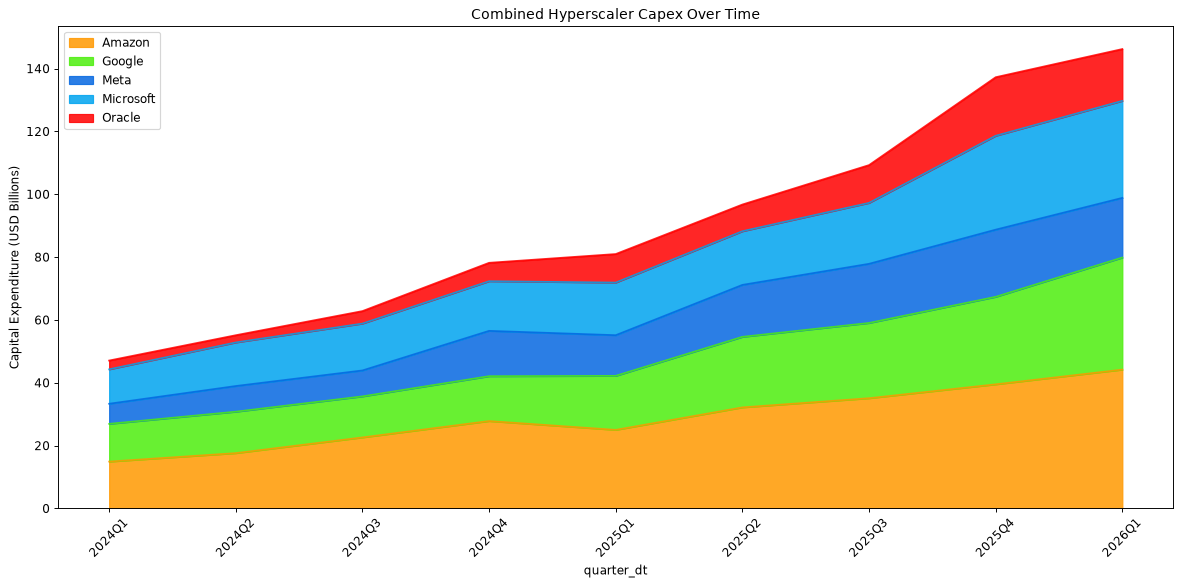

In [113]:
import matplotlib.pyplot as plt

colors = {
    "Microsoft": "#00A4EF",
    "Amazon": "#FF9900",
    "Meta": "#0668E1",
    "Google": "#4DEE0E",
    "Oracle": "#FF0000"
}

pivot = hyperscaler_raw.pivot(index="quarter_dt", columns="company", values="capex_bn").sort_index()
pivot.index = pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 7))
pivot.plot.area(ax=ax, color=[colors.get(c, "gray") for c in pivot.columns], alpha=0.85)

ax.set_ylabel("Capital Expenditure (USD Billions)")
ax.set_title("Combined Hyperscaler Capex Over Time")
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Amazon: 72.1%
Google: 72.3%
Meta: 72.3%
Microsoft: 67.9%
Oracle: 142.7%

Combined Hyperscaler Capex CAGR: 76.2%


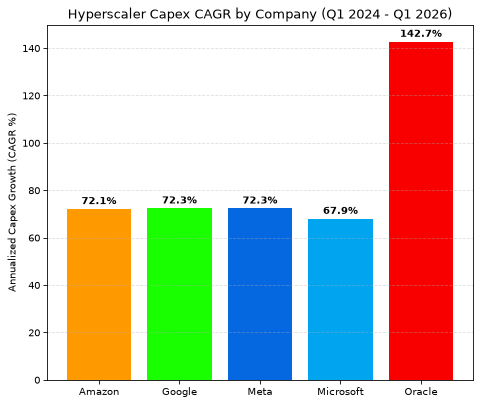

In [114]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 75

colors = {
    "Microsoft": "#00A4EF",
    "Amazon": "#FF9900",
    "Meta": "#0668E1",
    "Google": "#1AFF00",
    "Oracle": "#F80000"
}

#CAGR per company
cagr_by_company = {}

for company in hyperscaler_raw["company"].unique():
    company_data = hyperscaler_raw[hyperscaler_raw["company"] == company].sort_values("quarter_dt")
    capex_values = company_data["capex_bn"].tolist()
    
    start = capex_values[0]
    end = capex_values[-1]
    num_quarters = len(capex_values) - 1
    cagr = (end / start) ** (4 / num_quarters) - 1
    
    cagr_by_company[company] = cagr

for company, cagr in cagr_by_company.items():
    print(f"{company}: {cagr:.1%}")

#CAGR for combined total capex
total_by_quarter = hyperscaler_raw.groupby("quarter_dt")["capex_bn"].sum().sort_index()
total_values = total_by_quarter.tolist()

start = total_values[0]
end = total_values[-1]
num_quarters = len(total_values) - 1
total_cagr = (end / start) ** (4 / num_quarters) - 1

print(f"\nCombined Hyperscaler Capex CAGR: {total_cagr:.1%}")

#Bar chart of CAGR by company
companies = list(cagr_by_company.keys())
cagr_values = [cagr_by_company[c] * 100 for c in companies]  # convert to percentage

fig, ax = plt.subplots(figsize=(6.5, 5.5))

bars = ax.bar(companies, cagr_values, color=[colors.get(c, "gray") for c in companies])

for bar, value in zip(bars, cagr_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Annualized Capex Growth (CAGR %)")
ax.set_title("Hyperscaler Capex CAGR by Company (Q1 2024 - Q1 2026)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

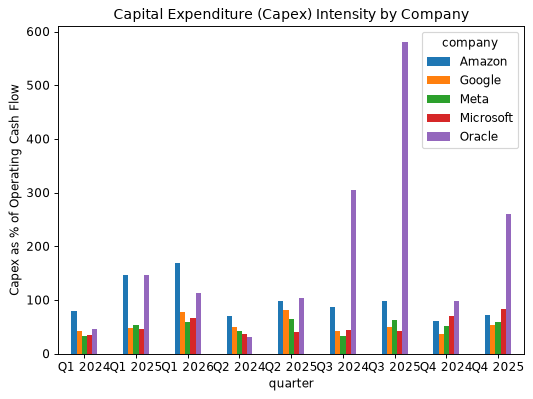

In [115]:
plt.rcParams["figure.dpi"] = 85

hyperscaler_raw["capex_pct_ocf"] = hyperscaler_raw["capex_bn"] / hyperscaler_raw["ocf_bn"] * 100
hyperscaler_raw["buyback_pct_ocf"] = hyperscaler_raw["buybacks_bn"] / hyperscaler_raw["ocf_bn"] * 100

pivot = hyperscaler_raw.pivot(index="quarter", columns="company", values="capex_pct_ocf")

fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Capex as % of Operating Cash Flow")
ax.set_title("Capital Expenditure (Capex) Intensity by Company")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


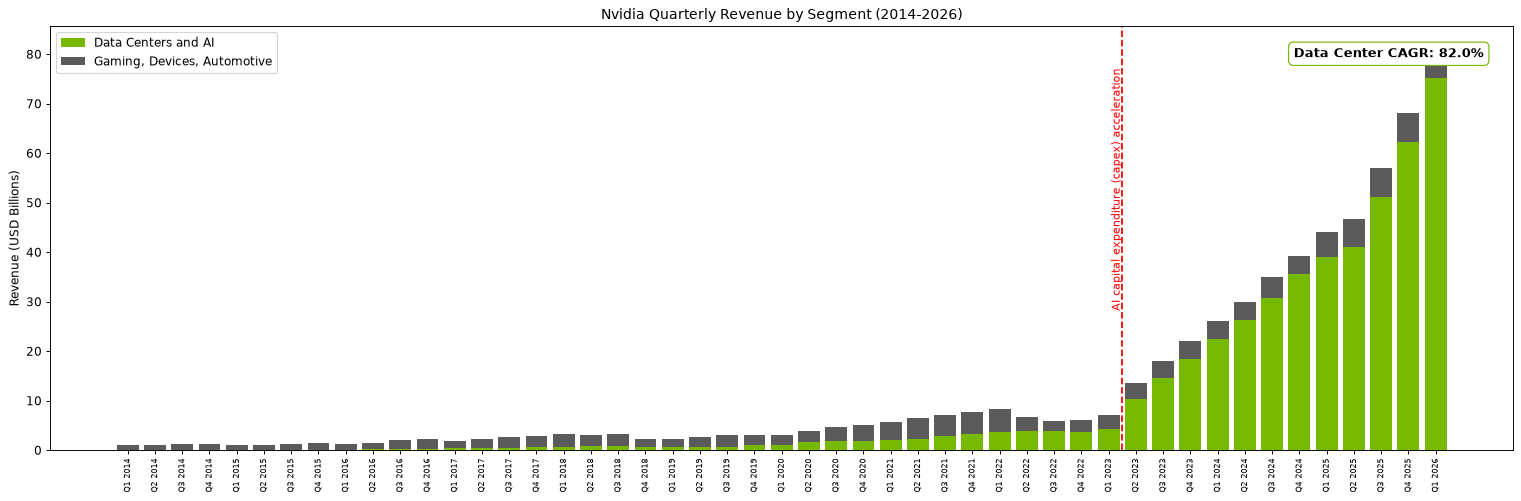

In [116]:
import pandas as pd
import matplotlib.pyplot as plt

#Load the data
df = pd.read_csv("nvidia_quarterly_revenue_segment_cleaned.csv")

#Pull out just the two segments we need
data_center = df[df["Revenue"] == "Data centers and AI"].reset_index(drop=True)
gaming = df[df["Revenue"] == "Gaming, devices, automotive"].reset_index(drop=True)
quarters = data_center["Quarter"].tolist()
dc_revenue = pd.to_numeric(data_center["NVIDIA's quarterly revenue (billion)"]).tolist()
gaming_revenue = pd.to_numeric(gaming["NVIDIA's quarterly revenue (billion)"]).tolist()

#Calculate CAGR (annualized growth rate)
start = dc_revenue[0]
end = dc_revenue[-1]
num_quarters = len(dc_revenue) - 1
cagr = (end / start) ** (4 / num_quarters) - 1

#Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(quarters, dc_revenue, label="Data Centers and AI", color="#76b900")
ax.bar(quarters, gaming_revenue, bottom=dc_revenue, label="Gaming, Devices, Automotive", color="#5b5b5b")
ax.set_ylabel("Revenue (USD Billions)")
ax.set_title("Nvidia Quarterly Revenue by Segment (2014-2026)")
ax.legend(loc="upper left")
ax.text(0.98, 0.95, f"Data Center CAGR: {cagr:.1%}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#76b900"))

#Mark AI capex acceleration point
split_index = quarters.index("Q1 2023")
ax.axvline(x=split_index+0.5, color="red", linestyle="--", linewidth=1.5, alpha=1)

ax.text(split_index + 0.5, ax.get_ylim()[1] * 0.9, "AI capital expenditure (capex) acceleration",
        rotation=90, color="red", fontsize=9, ha="right", va="top")

plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()